In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mt
import seaborn as sns
import os

os.makedirs('./charts', exist_ok=True)

file_path = 'financescraper/financescraper/spiders/output/largest_companies_revenue.csv'

df = pd.read_csv(
    file_path,
)

print(df.head())
print(df.shape)
print(df.describe())

   rank                               company     industry  revenue_usd_m  \
0     1                                Amazon       Retail         716924   
1     2                               Walmart       Retail         713163   
2     3       State Grid Corporation of China  Electricity         545948   
3     4                          Saudi Aramco  Oil and gas         480446   
4     5  China National Petroleum Corporation  Oil and gas         476000   

   profit_usd_m  employees        country  
0         79975    1576000  United States  
1         21893    2100000  United States  
2          9204    1361423          China  
3        106246      73311   Saudi Arabia  
4         25250    1026301          China  
(50, 7)
           rank  revenue_usd_m  profit_usd_m     employees
count  50.00000       50.00000      50.00000  5.000000e+01
mean   25.50000   278491.52000   29646.94000  3.351687e+05
std    14.57738   133824.24829   34663.24643  4.036986e+05
min     1.00000   156820.0000

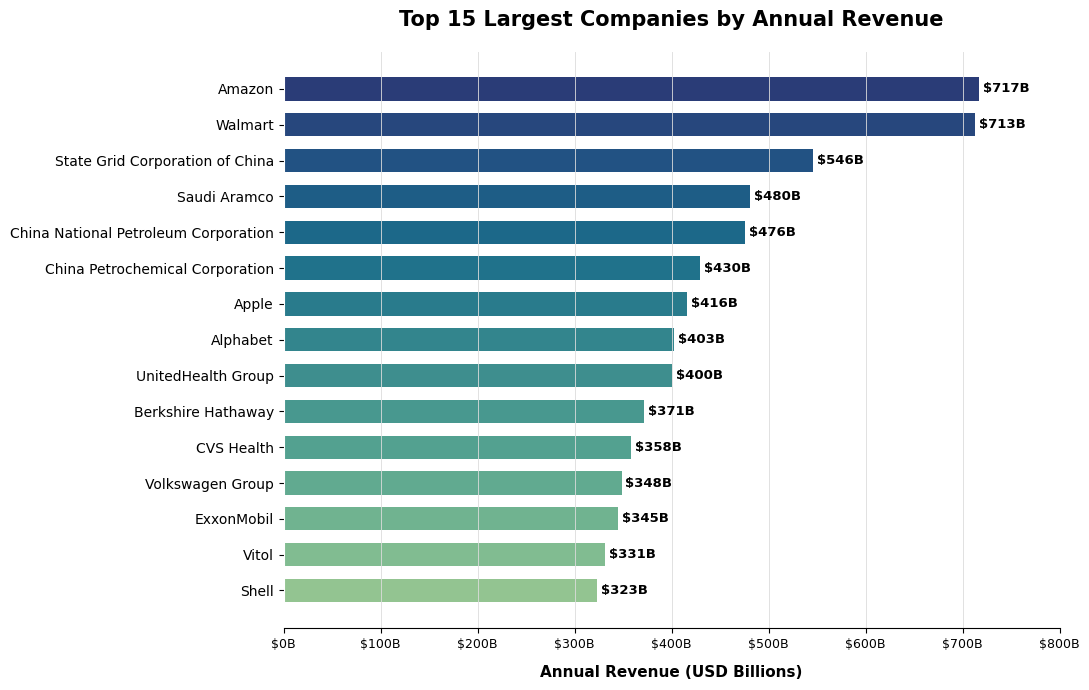

In [17]:


top15 = df.nlargest(15, "revenue_usd_m").sort_values("revenue_usd_m")

fig, ax = plt.subplots(figsize=(11, 7))

colors = sns.color_palette("crest", len(top15))

bars = ax.barh(
    top15["company"],
    top15["revenue_usd_m"] / 1000,
    edgecolor="none",
    height=0.65,
    color=colors
)

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 4,
        bar.get_y() + bar.get_height() / 2,
        f"${w:.0f}B",
        ha="left",
        va="center",
        fontsize=9.5,
        fontweight="bold"
    )

ax.set_xlabel("Annual Revenue (USD Billions)", fontsize=11,  fontweight="bold", labelpad=10,)
ax.set_title("Top 15 Largest Companies by Annual Revenue", fontsize=15, fontweight="bold", pad=18)
ax.set_xlim(0, 800)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9)
ax.xaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.grid(axis="x", linewidth=0.6, color="gainsboro")
ax.grid(axis="y", visible=False)
ax.spines["bottom"].set_color("black")
ax.spines["top"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["right"].set_color("white")


plt.tight_layout()
plt.savefig("./charts/chart1_top15_revenue.png",dpi=150, bbox_inches='tight')
plt.show()

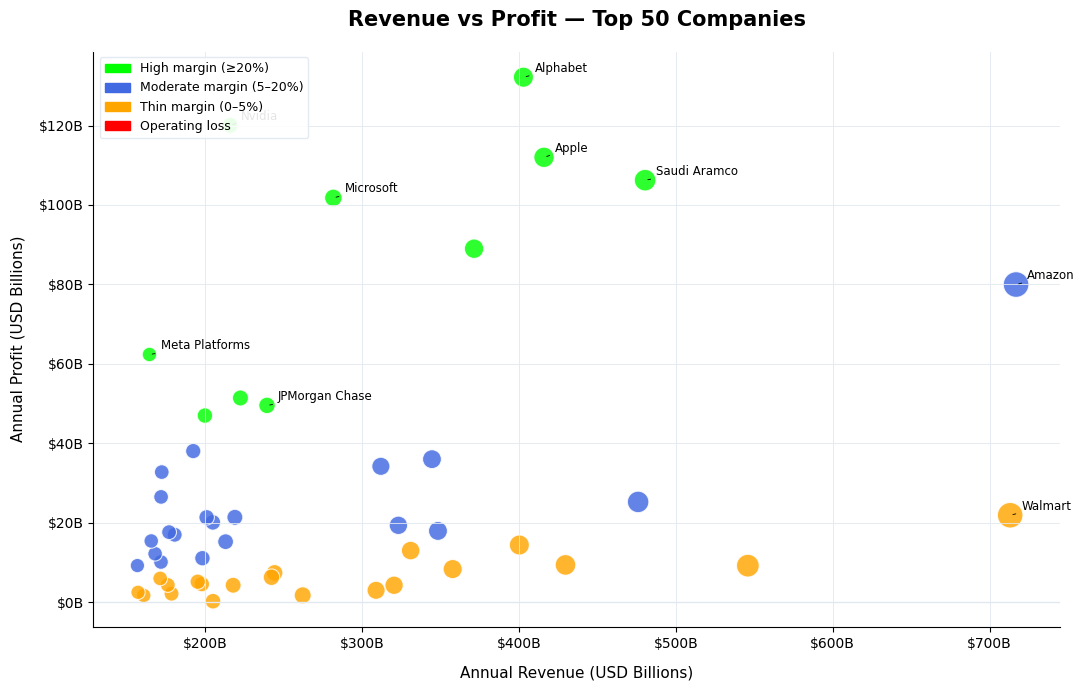

In [18]:
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

clean = df.dropna(subset=["profit_usd_m"]).copy()
clean["margin_pct"] = (clean["profit_usd_m"] / clean["revenue_usd_m"] * 100).clip(-5, 60)

# Color by margin
def margin_color(m):
    if m >= 20:  return "lime"
    if m >= 5:   return "royalblue"
    if m >= 0:   return "orange"
    return "red"

colors = [margin_color(m) for m in clean["margin_pct"]]
sizes  = (clean["revenue_usd_m"] / clean["revenue_usd_m"].max() * 300 + 40)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(clean["revenue_usd_m"] / 1000, clean["profit_usd_m"] / 1000,
                c=colors, s=sizes, alpha=0.82, edgecolors="white", linewidths=0.8)

# Label notable companies
labels = ["Amazon", "Walmart", "Apple", "Alphabet", "Nvidia",
          "Saudi Aramco", "Microsoft", "Meta Platforms", "JPMorgan Chase"]
for _, row in clean[clean["company"].isin(labels)].iterrows():
    ax.annotate(row["company"],
                xy=(row["revenue_usd_m"] / 1000, row["profit_usd_m"] / 1000),
                xytext=(8, 4), textcoords="offset points",
                fontsize=8.5,
                arrowprops=dict(arrowstyle="-", lw=0.6))

ax.set_xlabel("Annual Revenue (USD Billions)", fontsize=11, labelpad=10)
ax.set_ylabel("Annual Profit (USD Billions)", fontsize=11, labelpad=10)
ax.set_title("Revenue vs Profit — Top 50 Companies", fontsize=15,
             fontweight="bold", pad=18)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.axhline(0, color="#E2E8F0", linewidth=1)
ax.grid(color="#E2E8F0", linewidth=0.6)

legend_items = [
    mpatches.Patch(color="lime", label="High margin (≥20%)"),
    mpatches.Patch(color="royalblue",    label="Moderate margin (5–20%)"),
    mpatches.Patch(color="orange", label="Thin margin (0–5%)"),
    mpatches.Patch(color="red", label="Operating loss"),
]
ax.legend(handles=legend_items, fontsize=9, loc="upper left",
          framealpha=0.9, edgecolor="#E2E8F0")
ax.spines["top"].set_color("white")
ax.spines["right"].set_color("white")

plt.tight_layout()
plt.savefig("./charts/chart2_revenue_vs_profit.png",dpi=150, bbox_inches='tight')
plt.show()

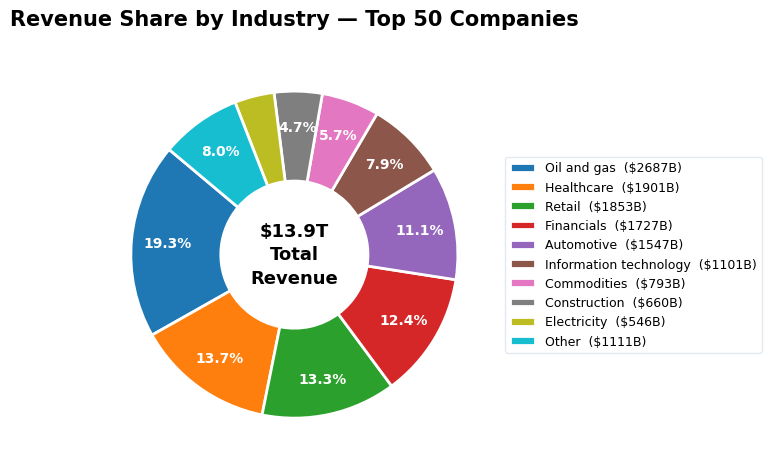

In [19]:
industry_rev = df.groupby("industry")["revenue_usd_m"].sum().sort_values(ascending=False)

threshold = industry_rev.sum() * 0.03
main = industry_rev[industry_rev >= threshold]
other = industry_rev[industry_rev < threshold].sum()
if other > 0:
    main["Other"] = other

fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    main.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 4 else "",
    startangle=140,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
    pctdistance=0.78,
)
for at in autotexts:
    at.set_color("white")
    at.set_fontsize(10)
    at.set_weight("bold")

ax.text(0, 0, f"${df['revenue_usd_m'].sum()/1_000_000:.1f}T\nTotal\nRevenue",
        ha="center", va="center", fontsize=13, fontweight="bold",
        linespacing=1.4)

# Legend
legend_labels = [f"{ind}  (${val/1000:.0f}B)" for ind, val in main.items()]
ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
          fontsize=9, framealpha=0.95, edgecolor="#E2E8F0")

plt.title("Revenue Share by Industry — Top 50 Companies",
             fontsize=15, fontweight="bold", pad=18)
plt.tight_layout()
plt.savefig("./charts/chart3_industry_revenue.png",dpi=150, bbox_inches='tight')
plt.show()

In [20]:
file_path = 'financescraper/financescraper/spiders/output/sp500_companies.csv'

df = pd.read_csv(
    file_path,
)

print(df.head())
print(df.shape)
print(df.describe())

       cik              company  date_added      founded  \
0    66740                   3M  1957-03-04         1902   
1    91142          A. O. Smith  2017-07-26         1916   
2     1800  Abbott Laboratories  1957-03-04         1888   
3  1551152               AbbVie  2012-12-31  2013 (1888)   
4  1467373            Accenture  2011-07-06         1989   

              headquarters                  sector  \
0    Saint Paul, Minnesota             Industrials   
1                Milwaukee             Industrials   
2  North Chicago, Illinois             Health Care   
3  North Chicago, Illinois             Health Care   
4                   Dublin  Information Technology   

                     sub_industry ticker  
0        Industrial Conglomerates    MMM  
1               Building Products    AOS  
2           Health Care Equipment    ABT  
3                   Biotechnology   ABBV  
4  IT Consulting & Other Services    ACN  
(503, 8)
                cik
count  5.030000e+02
mean   

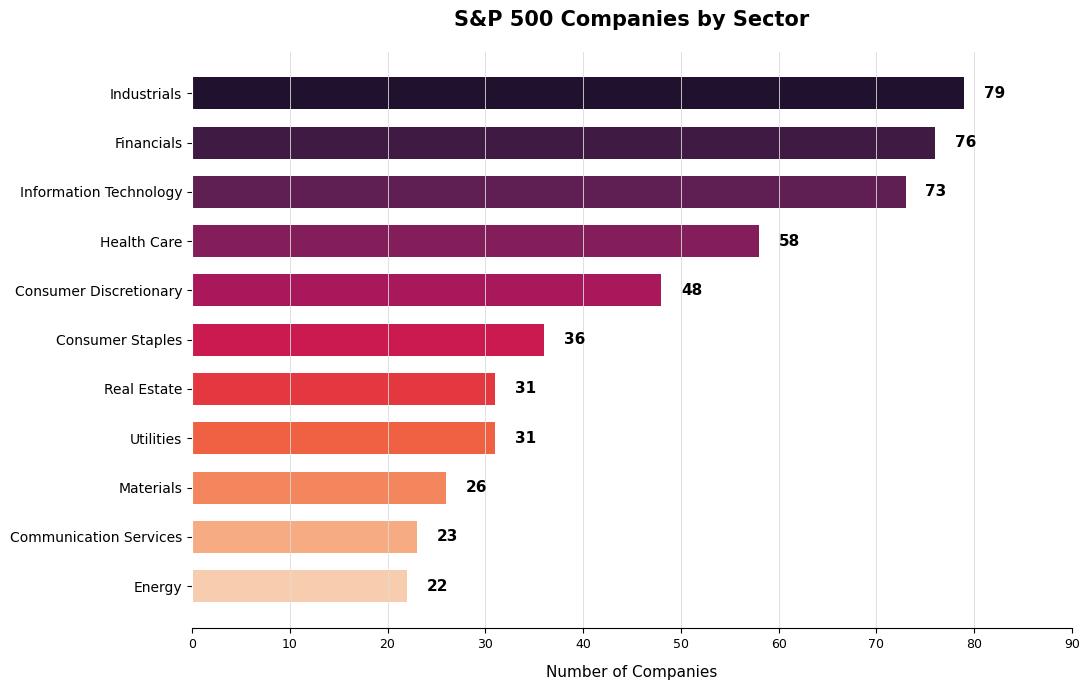

In [21]:
sector_counts = df["sector"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(11, 7))

colors = sns.color_palette("rocket_r", len(sector_counts))

bars = ax.barh(
    sector_counts.index,
    sector_counts.values,
    edgecolor="none",
    height=0.65,
    color=colors
)
for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 2,
        bar.get_y() + bar.get_height() / 2,
        str(int(w)),
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_xlabel("Number of Companies", fontsize=11, labelpad=10)
ax.set_title("S&P 500 Companies by Sector", fontsize=15, fontweight="bold", pad=18)
ax.set_xlim(0, 90)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9)
ax.xaxis.set_major_formatter(mt.FuncFormatter(lambda x, _: f"{x:.0f}"))
ax.grid(axis="x", linewidth=0.6, color="gainsboro")
ax.grid(axis="y", visible=False)
ax.spines["bottom"].set_color("black")
ax.spines["top"].set_color("white")
ax.spines["left"].set_color("white")
ax.spines["right"].set_color("white")

plt.tight_layout()
plt.savefig("./charts/chart4_sp500_sectors.png",dpi=150, bbox_inches='tight')
plt.show()